# Migration concentration and qualification level — England and Wales LADs

Recreates ONS Census 2021 Figure 4 ("London and the surrounding areas have high
migration and high qualification levels"): migration concentration ratio (x) vs
the share of migrants born outside the UK with Level 4+ qualifications (y), by
Upper Tier Local Authority, England and Wales, 2021.

- **Migration concentration** — relative measure of how much international
  migration a LAD attracted relative to its population size, compared to the
  England & Wales total (1.0 = in line with the E&W average).
- **% higher-qualified migrants** — share of migrants born outside the UK with
  Level 4 (degree) or above qualifications.

Wales LADs are highlighted in teal; England LADs are shown in grey, so the
England/Wales split in this migration-qualification relationship stands out.


## 1. Imports and paths

In [37]:
import pandas as pd
import altair as alt
from ecostyles import EcoStyles
styles = EcoStyles()
styles.register_and_enable_theme(theme_name="article")

alt.data_transformers.enable("default", max_rows=None)
alt.renderers.enable("png")  # renders as a plain image — no Vega extension needed to view in-notebook

BASE       = "/Users/h.cantekin/Library/CloudStorage/OneDrive-LondonSchoolofEconomics/Documents/GitHub/RADataHub/msa_map"
DATA_PATH  = f"{BASE}/data/raw/migration_qualification_data_EW.xlsx"
CHARTS_DIR = f"{BASE}/data/processed/charts"

TEAL         = "#2A9D8F"
NAVY         = "#1F3864"
BACKGROUND   = "#F5F4EF"
ENGLAND_GRAY = "#aaaaaa"


## 2. Load and clean

The sheet ships as an ONS-formatted release table: a title/notes block above
the data and a source/footnotes block below it. Rather than hard-code row
numbers, select rows whose first column is a genuine LAD GSS code
(`E` or `W` followed by 8 digits) — robust to the sheet being re-exported with
a different number of header rows.


In [38]:
raw = pd.read_excel(DATA_PATH, sheet_name="Figure4", header=None)

is_lad_row = raw[0].astype(str).str.match(r"^[EW]\d{8}$", na=False)
data = raw[is_lad_row].copy()
data.columns = ["lad_code", "lad_name", "migration_concentration", "pct_higher_ed"]
data["migration_concentration"] = data["migration_concentration"].astype(float)
data["pct_higher_ed"]           = data["pct_higher_ed"].astype(float)
data["country"] = data["lad_code"].str[0].map({"E": "England", "W": "Wales"})
data = data.reset_index(drop=True)

assert data[["migration_concentration", "pct_higher_ed"]].isna().sum().sum() == 0, "unexpected missing values"
print(f"{len(data)} LADs loaded — {data['country'].value_counts().to_dict()}")
data.head()


174 LADs loaded — {'England': 152, 'Wales': 22}


,lad_code,lad_name,migration_concentration,pct_higher_ed,country
0,E06000001,Hartlepool,0.23,33.33,England
1,E06000002,Middlesbrough,0.72,36.85,England
2,E06000003,Redcar and Cleveland,0.17,36.01,England
3,E06000004,Stockton-on-Tees,0.37,43.10,England
4,E06000005,Darlington,0.45,37.18,England


## 3. England & Wales averages

Unweighted mean across LADs within each country (each authority counted once,
regardless of population) — used for the reference crosshairs on the chart.


In [39]:
country_avg = data.groupby("country")[["migration_concentration", "pct_higher_ed"]].mean()
print(country_avg.round(3))

ENG_X, ENG_Y = country_avg.loc["England"]
WAL_X, WAL_Y = country_avg.loc["Wales"]


         migration_concentration  pct_higher_ed
country                                        
England                    1.146         42.843
Wales                      0.348         41.082


## 4. Save cleaned data

In [40]:
out_path = f"{BASE}/data/processed/migration_qualification_lad_2021.csv"
data.to_csv(out_path, index=False)
print(f"Saved {len(data)} rows to {out_path}")


Saved 174 rows to /Users/h.cantekin/Library/CloudStorage/OneDrive-LondonSchoolofEconomics/Documents/GitHub/RADataHub/msa_map/data/processed/migration_qualification_lad_2021.csv


## 5. Chart — migration concentration vs qualification level

England LADs in grey, Wales LADs in teal, with dashed crosshairs marking each
country's (unweighted) average on both axes.


Saved migration_qualification_ew.png


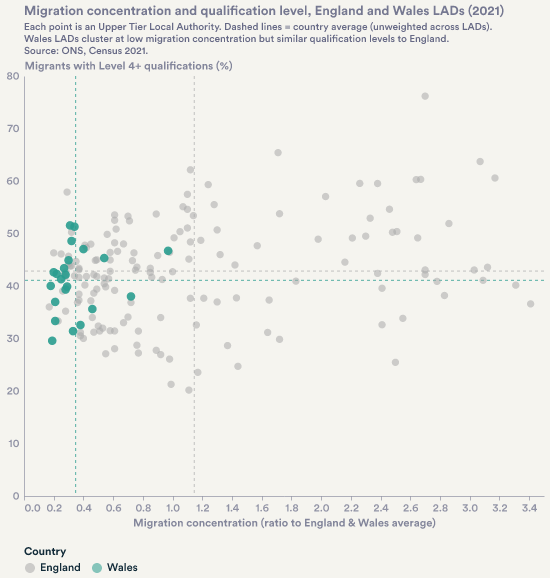

In [41]:
COLOR_SCALE = alt.Scale(domain=["England", "Wales"], range=[ENGLAND_GRAY, TEAL])

# ── Crosshairs — England ──────────────────────────────────────────────────
eng_point = pd.DataFrame([{"x": ENG_X, "y": ENG_Y, "label": "England average"}])
eng_h = alt.Chart(eng_point).mark_rule(color=ENGLAND_GRAY, strokeDash=[3, 3], opacity=0.7).encode(y="y:Q")
eng_v = alt.Chart(eng_point).mark_rule(color=ENGLAND_GRAY, strokeDash=[3, 3], opacity=0.7).encode(x="x:Q")

# ── Crosshairs — Wales ─────────────────────────────────────────────────────
wal_point = pd.DataFrame([{"x": WAL_X, "y": WAL_Y, "label": "Wales average"}])
wal_h = alt.Chart(wal_point).mark_rule(color=TEAL, strokeDash=[3, 3], opacity=0.8).encode(y="y:Q")
wal_v = alt.Chart(wal_point).mark_rule(color=TEAL, strokeDash=[3, 3], opacity=0.8).encode(x="x:Q")

# ── Scatter ────────────────────────────────────────────────────────────────
# Draw England first so the smaller Wales group of points sits visibly on top.
dots_england = alt.Chart(data[data["country"] == "England"]).mark_circle(size=55, opacity=0.55).encode(
    x=alt.X("migration_concentration:Q",
            title="Migration concentration (ratio to England & Wales average)",
            scale=alt.Scale(domain=[0, 3.5]),
            axis=alt.Axis(grid=False)),
    y=alt.Y("pct_higher_ed:Q",
            title="Migrants with Level 4+ qualifications (%)",
            scale=alt.Scale(domain=[15, 80]),
            axis=alt.Axis(grid=False)),
    color=alt.Color("country:N", scale=COLOR_SCALE, legend=alt.Legend(title="Country", orient="bottom")),
    tooltip=[
        alt.Tooltip("lad_name:N", title="Local authority"),
        alt.Tooltip("country:N", title="Country"),
        alt.Tooltip("migration_concentration:Q", title="Migration concentration", format=".2f"),
        alt.Tooltip("pct_higher_ed:Q", title="% Level 4+", format=".1f"),
    ],
)

dots_wales = alt.Chart(data[data["country"] == "Wales"]).mark_circle(size=75, opacity=0.9).encode(
    x=alt.X("migration_concentration:Q"),
    y=alt.Y("pct_higher_ed:Q"),
    color=alt.Color("country:N", scale=COLOR_SCALE),
    tooltip=[
        alt.Tooltip("lad_name:N", title="Local authority"),
        alt.Tooltip("country:N", title="Country"),
        alt.Tooltip("migration_concentration:Q", title="Migration concentration", format=".2f"),
        alt.Tooltip("pct_higher_ed:Q", title="% Level 4+", format=".1f"),
    ],
)

chart_migration = alt.layer(
    eng_h, eng_v, wal_h, wal_v, dots_england, dots_wales,
).properties(
    width=520, height=420,
    title=alt.TitleParams(
        text="Migration concentration and qualification level, England and Wales LADs (2021)",
        subtitle=[
            "Each point is an Upper Tier Local Authority. Dashed lines = country average (unweighted across LADs).",
            "Wales LADs cluster at low migration concentration but similar qualification levels to England.",
            "Source: ONS, Census 2021.",
        ],
        fontSize=13, subtitleFontSize=10, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_migration.save(f"{CHARTS_DIR}/migration_qualification_ew.png", scale_factor=2.5)
print("Saved migration_qualification_ew.png")

chart_migration


## 6. Figure 1 — Graduate attraction and retention by UK region (2018/19)

Recreates Figure 1 from the HESA Graduate Outcomes analysis (Table 1: regional
attraction and retention of new graduate workers, academic year 2018/19). Table 1
is a 12×12 provider-region × employment-region flow matrix; entered inline below
since it's a one-off published table, not a downloadable dataset.

- **Retention rate** — share of a region's own graduates who stay to work there
  (diagonal ÷ row total).
- **Attraction rate** — share of a region's graduate workforce drawn in from
  elsewhere (1 − diagonal ÷ column total).
- **Bubble size** — total new graduate workers from that provider region (row total).

Rates are derived from the flow matrix rather than typed in directly, then
cross-checked against the rates published alongside Table 1.


In [42]:
REGIONS = ["NE","NW","Y&H","EM","WM","EE","LD","SE","SW","Wales","ST","NI"]
REGION_LABELS = {
    "NE": "North East", "NW": "North West", "Y&H": "Yorkshire & the Humber",
    "EM": "East Midlands", "WM": "West Midlands", "EE": "East of England",
    "LD": "London", "SE": "South East", "SW": "South West", "Wales": "Wales",
    "ST": "Scotland", "NI": "Northern Ireland",
}

# Table 1 — provider region (row) x region of employment (column), academic year 2018/19.
# Source: HESA Graduate Outcomes Survey, 2018/19 cohort (rounded to nearest 5 in the original).
FLOW_MATRIX = {
    "NE":    [5695,   675,   940,   255,   220,   360,  1780,   520,   220,    70,   190,    85],
    "NW":    [ 350, 16065,  1335,   600,  1190,   550,  2070,   825,   515,   645,   250,   385],
    "Y&H":   [ 545,  2155, 10890,  1475,   715,   850,  2435,   980,   425,   150,   180,    50],
    "EM":    [ 215,   835,  1135,  7890,  1885,  1650,  3410,  1630,   645,   165,   140,    55],
    "WM":    [ 230,  1110,   535,  1255, 11170,   970,  3370,  1645,  1135,   365,   145,    65],
    "EE":    [  75,   260,   230,   420,   250,  6385,  3895,  1320,   345,    90,    85,    45],
    "LD":    [ 130,   570,   350,   405,   520,  2310, 28360,  4065,   830,   185,   295,    90],
    "SE":    [ 230,  1035,   685,   750,  1145,  2265,  9280, 14210,  2545,   430,   220,    90],
    "SW":    [  80,   430,   220,   325,   655,   745,  3850,  2505,  9125,   615,   135,    55],
    "Wales": [  60,   495,   155,   185,   590,   295,   970,   880,  1220,  7280,    85,    45],
    "ST":    [ 235,   500,   265,   200,   180,   325,  1650,   535,   285,    90, 18760,   250],
    "NI":    [  35,    65,    30,    35,    45,    50,   190,    80,    65,    25,    80,  5260],
}

flow = pd.DataFrame(FLOW_MATRIX, index=REGIONS).T  # rows = provider region, cols = region of employment

row_totals = flow.sum(axis=1)                       # total new graduate workers from each provider region
col_totals = flow.sum(axis=0)                        # total new graduate workers employed in each region
diagonal   = pd.Series({r: flow.loc[r, r] for r in REGIONS})

fig1 = pd.DataFrame({
    "region":          REGIONS,
    "region_label":    [REGION_LABELS[r] for r in REGIONS],
    "total_graduates": row_totals.values,
    "retention_rate":  (diagonal / row_totals * 100).values,
    "attraction_rate": ((col_totals - diagonal) / col_totals * 100).values,
})
fig1["is_wales"] = fig1["region"] == "Wales"

# Sanity check against the rates published alongside Table 1
PUBLISHED_RETENTION  = {"NE":51.7,"NW":64.8,"Y&H":52.2,"EM":40.1,"WM":50.8,"EE":47.6,
                         "LD":74.4,"SE":43.2,"SW":48.7,"Wales":59.4,"ST":80.6,"NI":88.3}
PUBLISHED_ATTRACTION = {"NE":27.7,"NW":33.6,"Y&H":35.1,"EM":42.8,"WM":39.8,"EE":61.9,
                         "LD":53.7,"SE":51.3,"SW":47.4,"Wales":28.0,"ST":8.8,"NI":18.8}
for r in REGIONS:
    row = fig1.set_index("region").loc[r]
    assert abs(row["retention_rate"] - PUBLISHED_RETENTION[r]) < 0.1, f"{r} retention mismatch"
    assert abs(row["attraction_rate"] - PUBLISHED_ATTRACTION[r]) < 0.1, f"{r} attraction mismatch"
assert row_totals.sum() == col_totals.sum() == 242920

UK_RETENTION  = diagonal.sum() / row_totals.sum() * 100
UK_ATTRACTION = (col_totals.sum() - diagonal.sum()) / col_totals.sum() * 100
print(f"Derived rates match published Table 1 exactly. UK retention {UK_RETENTION:.1f}%, UK attraction {UK_ATTRACTION:.1f}%")
fig1


Derived rates match published Table 1 exactly. UK retention 58.1%, UK attraction 41.9%


,region,region_label,total_graduates,retention_rate,attraction_rate,is_wales
0,NE,North East,11010,51.725704,27.728426,False
1,NW,North West,24780,64.830508,33.601984,False
2,Y&H,Yorkshire & the Humber,20850,52.230216,35.062612,False
3,EM,East Midlands,19655,40.142457,42.805364,False
4,WM,West Midlands,21995,50.784269,39.833019,False
5,EE,East of England,13400,47.649254,61.891973,False
6,LD,London,38110,74.416164,53.705517,False
7,SE,South East,32885,43.211191,51.327282,False
8,SW,South West,18740,48.692636,47.421492,False
9,Wales,Wales,12260,59.380098,27.992087,True


Saved graduate_attraction_retention_uk.png


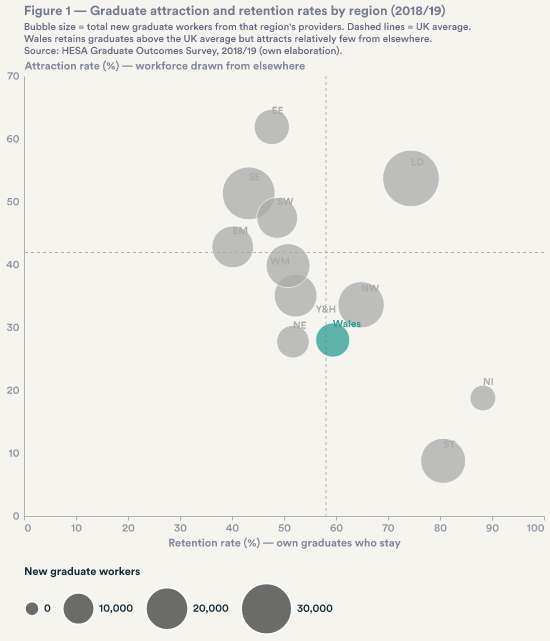

In [43]:
# ── Bubble chart ────────────────────────────────────────────────────────────
COLOR_SCALE_FIG1 = alt.Scale(domain=[False, True], range=[ENGLAND_GRAY, TEAL])

uk_point = pd.DataFrame([{"x": UK_RETENTION, "y": UK_ATTRACTION}])
uk_h = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(y="y:Q")
uk_v = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(x="x:Q")

bubbles = alt.Chart(fig1).mark_circle(opacity=0.75, stroke="white", strokeWidth=0.8).encode(
    x=alt.X("retention_rate:Q", title="Retention rate (%) — own graduates who stay",
            scale=alt.Scale(domain=[35, 95]), axis=alt.Axis(grid=False)),
    y=alt.Y("attraction_rate:Q", title="Attraction rate (%) — workforce drawn from elsewhere",
            scale=alt.Scale(domain=[0, 70]), axis=alt.Axis(grid=False)),
    size=alt.Size("total_graduates:Q", title="New graduate workers",
                  scale=alt.Scale(range=[200, 3200]),
                  legend=alt.Legend(orient="bottom", format=",.0f")),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG1, legend=None),
    tooltip=[
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("retention_rate:Q", title="Retention rate", format=".1f"),
        alt.Tooltip("attraction_rate:Q", title="Attraction rate", format=".1f"),
        alt.Tooltip("total_graduates:Q", title="New graduate workers", format=","),
    ],
)

# Manual nudges — WM/Y&H sit close together and otherwise collide
DX = {"WM": -18, "Y&H": 20}
DY = {"WM": -4,  "Y&H": 14}

label_layers = []
for _, row in fig1.iterrows():
    r = row["region"]
    label_layers.append(
        alt.Chart(pd.DataFrame([row])).mark_text(
            fontSize=10, fontWeight="bold",
            dx=DX.get(r, 0), dy=DY.get(r, -16),
            color=TEAL if row["is_wales"] else ENGLAND_GRAY,
        ).encode(x="retention_rate:Q", y="attraction_rate:Q", text="region:N")
    )

chart_fig1 = alt.layer(uk_h, uk_v, bubbles, *label_layers).properties(
    width=520, height=440,
    title=alt.TitleParams(
        text="Figure 1 — Graduate attraction and retention rates by region (2018/19)",
        subtitle=[
            "Bubble size = total new graduate workers from that region's providers. Dashed lines = UK average.",
            "Wales retains graduates above the UK average but attracts relatively few from elsewhere.",
            "Source: HESA Graduate Outcomes Survey, 2018/19 (own elaboration).",
        ],
        fontSize=13, subtitleFontSize=10, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_fig1.save(f"{CHARTS_DIR}/graduate_attraction_retention_uk.png", scale_factor=2.5)
print("Saved graduate_attraction_retention_uk.png")

chart_fig1


## 7. Figure 1b — simple scatter version (no bubble sizing)

Same retention/attraction rates and Wales highlight as Figure 1, but as a plain
scatter with fixed-size points and full region name labels — no size legend, for
contexts where the bubble-size encoding isn't wanted.


Saved graduate_attraction_retention_uk_scatter.png


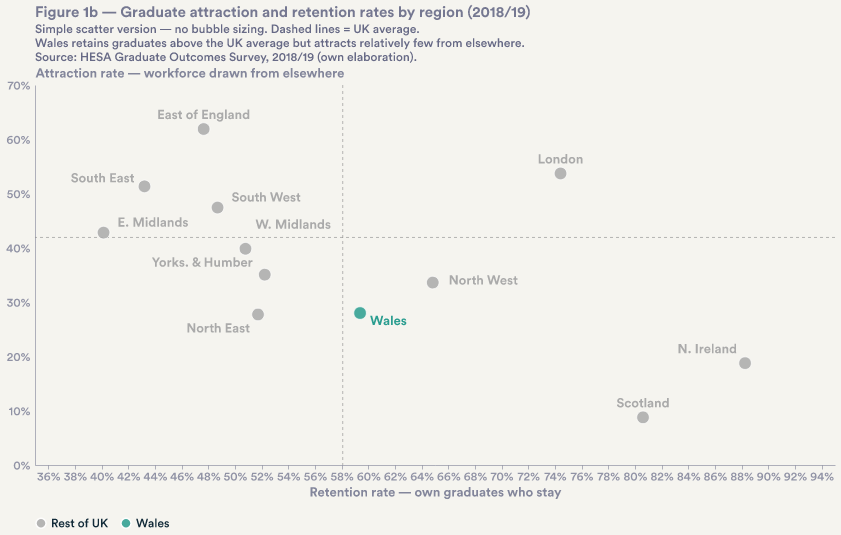

In [44]:
# ── Simple scatter version — full-text region labels (short-form where needed
# to keep the crowded England-regions cluster legible) and "%" axis labels.
REGION_SHORT = {
    "NE": "North East", "NW": "North West", "Y&H": "Yorks. & Humber",
    "EM": "E. Midlands", "WM": "W. Midlands", "EE": "East of England",
    "LD": "London", "SE": "South East", "SW": "South West",
    "Wales": "Wales", "ST": "Scotland", "NI": "N. Ireland",
}
fig1["region_short"] = fig1["region"].map(REGION_SHORT)

uk_h_b = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(y="y:Q")
uk_v_b = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(x="x:Q")

dots_fig1b = alt.Chart(fig1).mark_circle(size=160, opacity=0.85, stroke="white", strokeWidth=0.8).encode(
    x=alt.X("retention_rate:Q", title="Retention rate — own graduates who stay",
            scale=alt.Scale(domain=[35, 95], nice=False, zero=False),
            axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13)),
    y=alt.Y("attraction_rate:Q", title="Attraction rate — workforce drawn from elsewhere",
            scale=alt.Scale(domain=[0, 70], nice=False, zero=False),
            axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13)),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG1,
                    legend=alt.Legend(title=None, orient="bottom", labelFontSize=12,
                                       labelExpr="datum.label == \'true\' ? \'Wales\' : \'Rest of UK\'")),
    tooltip=[
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("retention_rate:Q", title="Retention rate", format=".1f"),
        alt.Tooltip("attraction_rate:Q", title="Attraction rate", format=".1f"),
    ],
)

# Manual placement — the NE/NW/Y&H/WM/Wales cluster needs each label pushed in a
# different direction to clear the longer text; the rest have enough clear space
# for a plain above/below nudge. EM sits to the right of its point (not left)
# to keep clear of the Yorks./North East labels further down.
LABEL_POS = {
    "NE":    {"dx": -8,  "dy": 14,  "align": "right"},
    "NW":    {"dx": 16,  "dy": -2,  "align": "left"},
    "Y&H":   {"dx": -12, "dy": -12, "align": "right"},
    "WM":    {"dx": 10,  "dy": -24, "align": "left"},
    "Wales": {"dx": 10,  "dy": 8,   "align": "left"},
    "EM":    {"dx": 14,  "dy": -10, "align": "left"},
    "EE":    {"dx": 0,   "dy": -14, "align": "center"},
    "LD":    {"dx": 0,   "dy": -14, "align": "center"},
    "SE":    {"dx": -10, "dy": -8,  "align": "right"},
    "SW":    {"dx": 14,  "dy": -10, "align": "left"},
    "ST":    {"dx": 0,   "dy": -14, "align": "center"},
    "NI":    {"dx": -8,  "dy": -14, "align": "right"},
}

label_layers_b = []
for _, row in fig1.iterrows():
    pos = LABEL_POS[row["region"]]
    label_layers_b.append(
        alt.Chart(pd.DataFrame([row])).mark_text(
            fontSize=13, fontWeight="bold",
            dx=pos["dx"], dy=pos["dy"], align=pos["align"],
            color=TEAL if row["is_wales"] else ENGLAND_GRAY,
        ).encode(x="retention_rate:Q", y="attraction_rate:Q", text="region_short:N")
    )

chart_fig1b = alt.layer(uk_h_b, uk_v_b, dots_fig1b, *label_layers_b).properties(
    width=800, height=380,
    title=alt.TitleParams(
        text="Figure 1b — Graduate attraction and retention rates by region (2018/19)",
        subtitle=[
            "Simple scatter version — no bubble sizing. Dashed lines = UK average.",
            "Wales retains graduates above the UK average but attracts relatively few from elsewhere.",
            "Source: HESA Graduate Outcomes Survey, 2018/19 (own elaboration).",
        ],
        fontSize=15, subtitleFontSize=12, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_fig1b.save(f"{CHARTS_DIR}/graduate_attraction_retention_uk_scatter.png", scale_factor=2.5)
print("Saved graduate_attraction_retention_uk_scatter.png")

chart_fig1b


## 8. Table 4 — retention & attraction by skill level: Wales vs UK, Scotland, NI

Table 4 breaks the same retention/attraction rates down by level of skilled
employment (High/Medium/Low, defined by SOC major group). Focus on Wales
against the UK average and the two other nations with a devolved graduate
labour market, Scotland and Northern Ireland — both of which retain graduates
at much higher rates than anywhere in England.

Colour set (validated with the skill's palette checker, light-mode, all-pairs):
Wales keeps the notebook's teal; UK is a neutral grey benchmark rather than a
categorical hue (it isn't a "peer" being compared so much as the reference
line); Scotland and Northern Ireland take two more validated hues.


In [45]:
# Table 4 — entered directly (published as rates only, no underlying counts to
# re-derive them from, unlike Table 1's flow matrix).
TABLE4_RETENTION = {
    "NE": (50.5, 54.6, 57.8), "NW": (64.4, 65.0, 67.2), "Y&H": (51.0, 55.7, 56.4),
    "EM": (39.4, 40.9, 43.9), "WM": (49.4, 55.0, 56.2), "EE": (47.6, 45.8, 51.2),
    "LD": (74.1, 76.7, 73.4), "SE": (42.6, 43.6, 47.2), "SW": (47.8, 51.1, 51.9),
    "Wales": (58.9, 62.3, 57.5), "ST": (78.4, 86.3, 89.4), "NI": (87.0, 92.9, 93.8),
    "UK": (57.4, 59.7, 61.1),
}
TABLE4_ATTRACTION = {
    "NE": (27.7, 24.3, 29.4), "NW": (33.7, 35.0, 32.1), "Y&H": (34.9, 35.7, 35.3),
    "EM": (44.0, 39.3, 40.1), "WM": (39.0, 40.6, 44.3), "EE": (60.8, 63.6, 67.3),
    "LD": (54.6, 51.9, 47.7), "SE": (52.1, 49.4, 47.9), "SW": (47.7, 47.6, 45.6),
    "Wales": (29.0, 23.1, 27.5), "ST": (9.9, 5.7, 5.1), "NI": (17.3, 19.8, 27.1),
    "UK": (42.6, 40.3, 38.9),
}
SKILL_LEVELS = ["High-skilled", "Medium-skilled", "Low-skilled"]

FOCUS_LABELS = {"Wales": "Wales", "UK": "UK average", "ST": "Scotland", "NI": "Northern Ireland"}
FOCUS_ORDER  = ["Wales", "UK average", "Scotland", "Northern Ireland"]
FOCUS_COLORS = {
    "Wales":            TEAL,       # consistent with the rest of the notebook
    "UK average":       "#4d4d4d",  # neutral benchmark, not a categorical hue
    "Scotland":         "#eb6834",  # validated categorical slot (orange)
    "Northern Ireland": "#4a3aa7",  # validated categorical slot (violet)
}

rows = []
for region, label in FOCUS_LABELS.items():
    ret = TABLE4_RETENTION[region]
    att = TABLE4_ATTRACTION[region]
    for i, skill in enumerate(SKILL_LEVELS):
        rows.append({"region_label": label, "skill_level": skill, "metric": "Retention rate", "rate": ret[i]})
        rows.append({"region_label": label, "skill_level": skill, "metric": "Attraction rate", "rate": att[i]})
table4_focus = pd.DataFrame(rows)
table4_focus["zero"] = 0

COLOR_SCALE_T4 = alt.Scale(domain=FOCUS_ORDER, range=[FOCUS_COLORS[r] for r in FOCUS_ORDER])
table4_focus.head(12)


,region_label,skill_level,metric,rate,zero
0,Wales,High-skilled,Retention rate,58.9,0
1,Wales,High-skilled,Attraction rate,29.0,0
2,Wales,Medium-skilled,Retention rate,62.3,0
3,Wales,Medium-skilled,Attraction rate,23.1,0
4,Wales,Low-skilled,Retention rate,57.5,0
5,Wales,Low-skilled,Attraction rate,27.5,0
6,UK average,High-skilled,Retention rate,57.4,0
7,UK average,High-skilled,Attraction rate,42.6,0
8,UK average,Medium-skilled,Retention rate,59.7,0
9,UK average,Medium-skilled,Attraction rate,40.3,0


### Option A — lollipop chart

Saved graduate_skill_level_wales_uk_scotland_ni_lollipop.png


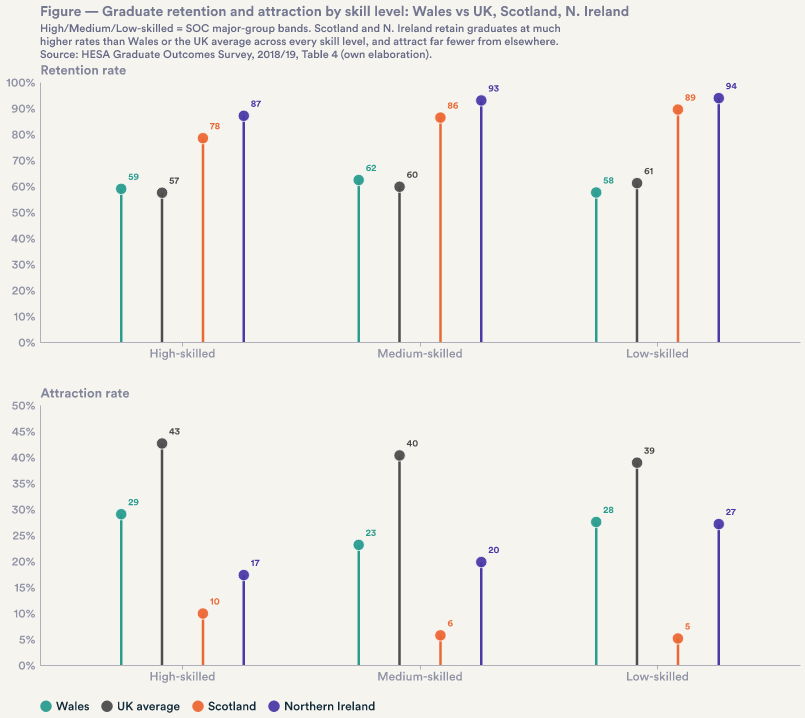

In [46]:
def lollipop_panel(metric_name, y_domain, y_title):
    d = table4_focus[table4_focus["metric"] == metric_name]

    x_enc = alt.X("skill_level:N", sort=SKILL_LEVELS, title=None,
                  axis=alt.Axis(labelAngle=0, labelFontSize=12))
    xoff  = alt.XOffset("region_label:N", sort=FOCUS_ORDER,
                        scale=alt.Scale(paddingOuter=0.4, paddingInner=0.15))
    y_enc = alt.Y("rate:Q", title=y_title,
                  scale=alt.Scale(domain=y_domain, nice=False, zero=True),
                  axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13))
    color_enc = alt.Color("region_label:N", scale=COLOR_SCALE_T4,
                          legend=alt.Legend(title=None, orient="bottom", labelFontSize=12))
    tooltip = [
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("skill_level:N", title="Skill level"),
        alt.Tooltip("rate:Q", title=metric_name, format=".1f"),
    ]

    stems = alt.Chart(d).mark_rule(strokeWidth=2.5).encode(
        x=x_enc, xOffset=xoff, y=y_enc, y2="zero:Q", color=color_enc)
    dots = alt.Chart(d).mark_circle(size=130, opacity=0.95, stroke="white", strokeWidth=0.8).encode(
        x=x_enc, xOffset=xoff, y=y_enc, color=color_enc, tooltip=tooltip)
    labels = alt.Chart(d).mark_text(dy=-12, fontSize=9.5, fontWeight="bold").encode(
        x=x_enc, xOffset=xoff, y=y_enc, color=color_enc,
        text=alt.Text("rate:Q", format=".0f"))

    return alt.layer(stems, dots, labels).properties(width=760, height=260)

lollipop_chart = alt.vconcat(
    lollipop_panel("Retention rate", [0, 100], "Retention rate"),
    lollipop_panel("Attraction rate", [0, 50], "Attraction rate"),
    spacing=28,
).properties(
    title=alt.TitleParams(
        text="Figure — Graduate retention and attraction by skill level: Wales vs UK, Scotland, N. Ireland",
        subtitle=[
            "High/Medium/Low-skilled = SOC major-group bands. Scotland and N. Ireland retain graduates at much",
            "higher rates than Wales or the UK average across every skill level, and attract far fewer from elsewhere.",
            "Source: HESA Graduate Outcomes Survey, 2018/19, Table 4 (own elaboration).",
        ],
        fontSize=14, subtitleFontSize=11, anchor="start",
    )
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

lollipop_chart.save(f"{CHARTS_DIR}/graduate_skill_level_wales_uk_scotland_ni_lollipop.png", scale_factor=2.5)
print("Saved graduate_skill_level_wales_uk_scotland_ni_lollipop.png")

lollipop_chart


### Option B — grouped bar chart

Saved graduate_skill_level_wales_uk_scotland_ni_bar.png


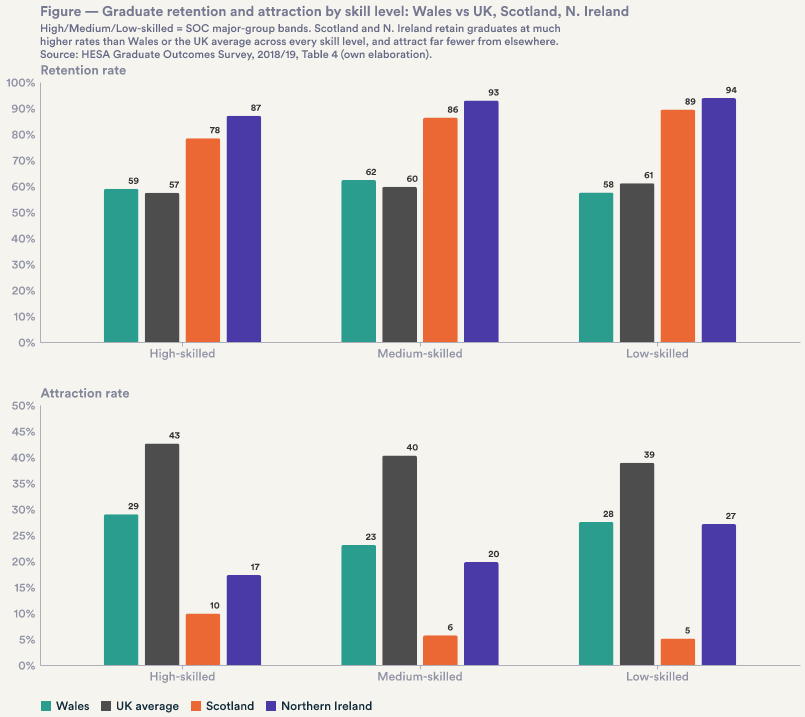

In [47]:
def bar_panel(metric_name, y_domain, y_title):
    d = table4_focus[table4_focus["metric"] == metric_name]

    x_enc = alt.X("skill_level:N", sort=SKILL_LEVELS, title=None,
                  axis=alt.Axis(labelAngle=0, labelFontSize=12))
    xoff  = alt.XOffset("region_label:N", sort=FOCUS_ORDER,
                        scale=alt.Scale(paddingOuter=0.4, paddingInner=0.15))
    y_enc = alt.Y("rate:Q", title=y_title,
                  scale=alt.Scale(domain=y_domain, nice=False, zero=True),
                  axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13))
    color_enc = alt.Color("region_label:N", scale=COLOR_SCALE_T4,
                          legend=alt.Legend(title=None, orient="bottom", labelFontSize=12))
    tooltip = [
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("skill_level:N", title="Skill level"),
        alt.Tooltip("rate:Q", title=metric_name, format=".1f"),
    ]

    bars = alt.Chart(d).mark_bar(cornerRadiusTopLeft=2, cornerRadiusTopRight=2).encode(
        x=x_enc, xOffset=xoff, y=y_enc, color=color_enc, tooltip=tooltip)
    labels = alt.Chart(d).mark_text(dy=-8, fontSize=9.5, fontWeight="bold", color="#333333").encode(
        x=x_enc, xOffset=xoff, y=y_enc, text=alt.Text("rate:Q", format=".0f"))

    return alt.layer(bars, labels).properties(width=760, height=260)

bar_chart = alt.vconcat(
    bar_panel("Retention rate", [0, 100], "Retention rate"),
    bar_panel("Attraction rate", [0, 50], "Attraction rate"),
    spacing=28,
).properties(
    title=alt.TitleParams(
        text="Figure — Graduate retention and attraction by skill level: Wales vs UK, Scotland, N. Ireland",
        subtitle=[
            "High/Medium/Low-skilled = SOC major-group bands. Scotland and N. Ireland retain graduates at much",
            "higher rates than Wales or the UK average across every skill level, and attract far fewer from elsewhere.",
            "Source: HESA Graduate Outcomes Survey, 2018/19, Table 4 (own elaboration).",
        ],
        fontSize=14, subtitleFontSize=11, anchor="start",
    )
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

bar_chart.save(f"{CHARTS_DIR}/graduate_skill_level_wales_uk_scotland_ni_bar.png", scale_factor=2.5)
print("Saved graduate_skill_level_wales_uk_scotland_ni_bar.png")

bar_chart


## 9. Figure 4 (Russell Group panel) — graduate retention by region

Recreates the retention series from Figure 4's Russell Group panel (graduate
attraction and retention rates by region and type of university attended) as
a horizontal bar chart, retention only, sorted by rate, with Wales highlighted
and a dashed reference line at the UK figure.


Saved graduate_retention_russell_group_by_region.png


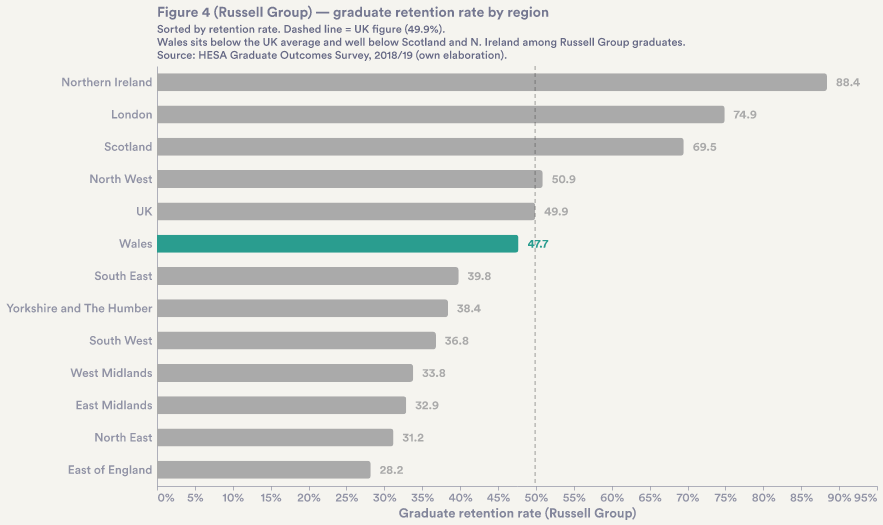

In [48]:
# Figure 4, Russell Group panel — graduate retention rate by region (%)
FIG4_RUSSELL_RETENTION = {
    "North East": 31.2, "North West": 50.9, "Yorkshire and The Humber": 38.4,
    "East Midlands": 32.9, "West Midlands": 33.8, "East of England": 28.2,
    "London": 74.9, "South East": 39.8, "South West": 36.8,
    "Wales": 47.7, "Scotland": 69.5, "Northern Ireland": 88.4, "UK": 49.9,
}

fig4 = pd.DataFrame(
    [{"region": r, "retention_rate": v} for r, v in FIG4_RUSSELL_RETENTION.items()]
)
fig4["is_wales"] = fig4["region"] == "Wales"
fig4 = fig4.sort_values("retention_rate", ascending=False).reset_index(drop=True)
REGION_SORT_FIG4 = fig4["region"].tolist()

UK_RUSSELL_RETENTION = FIG4_RUSSELL_RETENTION["UK"]
uk_rule_df = pd.DataFrame([{"x": UK_RUSSELL_RETENTION}])

COLOR_SCALE_FIG4 = alt.Scale(domain=[False, True], range=[ENGLAND_GRAY, TEAL])

bars_fig4 = alt.Chart(fig4).mark_bar(height=18, cornerRadiusEnd=3).encode(
    y=alt.Y("region:N", sort=REGION_SORT_FIG4, title=None,
            axis=alt.Axis(labelFontSize=12, grid=False)),
    x=alt.X("retention_rate:Q", title="Graduate retention rate (Russell Group)",
            scale=alt.Scale(domain=[0, 95], nice=False, zero=True),
            axis=alt.Axis(grid=False, labelExpr="datum.value + \'%\'", labelFontSize=12, titleFontSize=13)),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG4, legend=None),
    tooltip=[alt.Tooltip("region:N", title="Region"),
             alt.Tooltip("retention_rate:Q", title="Retention rate", format=".1f")],
)

labels_fig4 = alt.Chart(fig4).mark_text(align="left", dx=9, fontSize=12, fontWeight="bold").encode(
    y=alt.Y("region:N", sort=REGION_SORT_FIG4),
    x=alt.X("retention_rate:Q"),
    text=alt.Text("retention_rate:Q", format=".1f"),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG4, legend=None),
)

uk_rule = alt.Chart(uk_rule_df).mark_rule(
    color="#444444", strokeDash=[4, 3], strokeWidth=1.2, opacity=0.4
).encode(x="x:Q")

chart_fig4 = alt.layer(bars_fig4, uk_rule, labels_fig4).properties(
    width=720, height=420,
    title=alt.TitleParams(
        text="Figure 4 (Russell Group) — graduate retention rate by region",
        subtitle=[
            "Sorted by retention rate. Dashed line = UK figure (49.9%).",
            "Wales sits below the UK average and well below Scotland and N. Ireland among Russell Group graduates.",
            "Source: HESA Graduate Outcomes Survey, 2018/19 (own elaboration).",
        ],
        fontSize=14, subtitleFontSize=11, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_fig4.save(f"{CHARTS_DIR}/graduate_retention_russell_group_by_region.png", scale_factor=2.5)
print("Saved graduate_retention_russell_group_by_region.png")

chart_fig4


## 10. Figure 4 (Russell Group panel) — graduate attraction by region

Same recreation, attraction rate this time. Sorted highest-to-lowest top-to-bottom
(same convention now applied to the retention chart above), Wales highlighted,
dashed line at the UK figure.


Saved graduate_attraction_russell_group_by_region.png


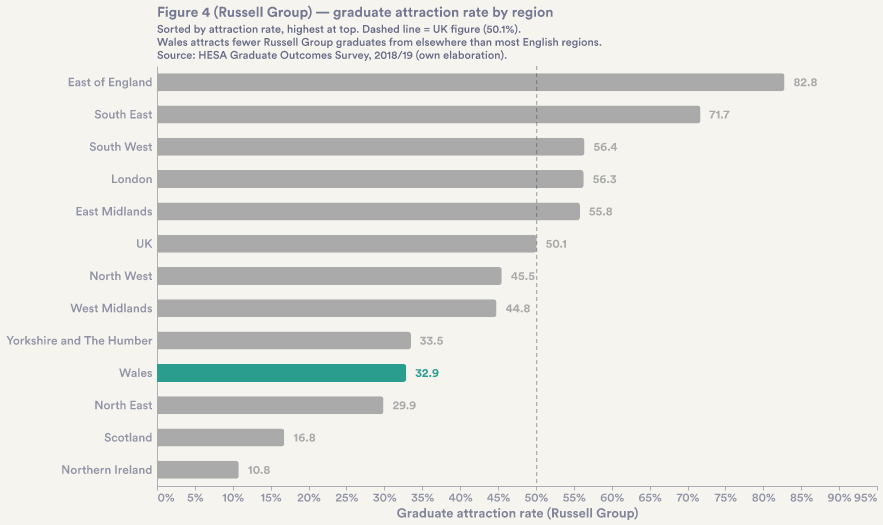

In [49]:
# Figure 4, Russell Group panel — graduate attraction rate by region (%)
FIG4_RUSSELL_ATTRACTION = {
    "North East": 29.9, "North West": 45.5, "Yorkshire and The Humber": 33.5,
    "East Midlands": 55.8, "West Midlands": 44.8, "East of England": 82.8,
    "London": 56.3, "South East": 71.7, "South West": 56.4,
    "Wales": 32.9, "Scotland": 16.8, "Northern Ireland": 10.8, "UK": 50.1,
}

fig4_att = pd.DataFrame(
    [{"region": r, "attraction_rate": v} for r, v in FIG4_RUSSELL_ATTRACTION.items()]
)
fig4_att["is_wales"] = fig4_att["region"] == "Wales"
fig4_att = fig4_att.sort_values("attraction_rate", ascending=False).reset_index(drop=True)
REGION_SORT_FIG4_ATT = fig4_att["region"].tolist()

UK_RUSSELL_ATTRACTION = FIG4_RUSSELL_ATTRACTION["UK"]
uk_rule_att_df = pd.DataFrame([{"x": UK_RUSSELL_ATTRACTION}])

bars_fig4_att = alt.Chart(fig4_att).mark_bar(height=18, cornerRadiusEnd=3).encode(
    y=alt.Y("region:N", sort=REGION_SORT_FIG4_ATT, title=None,
            axis=alt.Axis(labelFontSize=12, grid=False)),
    x=alt.X("attraction_rate:Q", title="Graduate attraction rate (Russell Group)",
            scale=alt.Scale(domain=[0, 95], nice=False, zero=True),
            axis=alt.Axis(grid=False, labelExpr="datum.value + \'%\'", labelFontSize=12, titleFontSize=13)),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG4, legend=None),
    tooltip=[alt.Tooltip("region:N", title="Region"),
             alt.Tooltip("attraction_rate:Q", title="Attraction rate", format=".1f")],
)

labels_fig4_att = alt.Chart(fig4_att).mark_text(align="left", dx=9, fontSize=12, fontWeight="bold").encode(
    y=alt.Y("region:N", sort=REGION_SORT_FIG4_ATT),
    x=alt.X("attraction_rate:Q"),
    text=alt.Text("attraction_rate:Q", format=".1f"),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG4, legend=None),
)

uk_rule_att = alt.Chart(uk_rule_att_df).mark_rule(
    color="#444444", strokeDash=[4, 3], strokeWidth=1.2, opacity=0.4
).encode(x="x:Q")

chart_fig4_att = alt.layer(bars_fig4_att, uk_rule_att, labels_fig4_att).properties(
    width=720, height=420,
    title=alt.TitleParams(
        text="Figure 4 (Russell Group) — graduate attraction rate by region",
        subtitle=[
            "Sorted by attraction rate, highest at top. Dashed line = UK figure (50.1%).",
            "Wales attracts fewer Russell Group graduates from elsewhere than most English regions.",
            "Source: HESA Graduate Outcomes Survey, 2018/19 (own elaboration).",
        ],
        fontSize=14, subtitleFontSize=11, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_fig4_att.save(f"{CHARTS_DIR}/graduate_attraction_russell_group_by_region.png", scale_factor=2.5)
print("Saved graduate_attraction_russell_group_by_region.png")

chart_fig4_att


## 11. Table 3 — retention & attraction by industry sector: Wales vs UK, Scotland, NI

Table 3 breaks the same retention/attraction rates down by grouped industry
sector (SIC-based, aggregated per the Labour Force Survey structure). Same
four-way comparison as Section 8 (Wales, UK average, Scotland, Northern
Ireland), same validated colour set, now across the 9 published sectors —
only the values for these four regions/rows are transcribed, since Table 3's
other 9 regions aren't needed for this comparison.

None of Wales/UK/Scotland/NI have a disclosure-suppressed (`*`) cell in
Table 3, so no missing-data handling is needed for this subset.


In [50]:
SECTORS = [
    "Agriculture, forestry & fishing", "Energy & water", "Manufacturing", "Construction",
    "Distribution, hotels & restaurants", "Transport & communication", "Banking & finance",
    "Public admin, education & health", "Other services",
]

TABLE3_RETENTION_FOCUS = {
    "Wales": (63.6, 60.0, 57.4, 63.0, 56.0, 41.0, 50.4, 66.6, 54.1),
    "UK":    (51.6, 56.9, 48.5, 52.4, 58.2, 49.3, 50.1, 64.9, 57.0),
    "ST":    (100.0, 85.8, 68.7, 78.2, 87.1, 69.8, 72.6, 84.9, 82.3),
    "NI":    (100.0, 100.0, 91.4, 85.7, 91.7, 91.1, 91.1, 86.6, 93.8),
}
TABLE3_ATTRACTION_FOCUS = {
    "Wales": (36.4, 6.3, 32.5, 21.6, 29.5, 28.1, 34.0, 24.6, 30.5),
    "UK":    (48.4, 43.1, 51.5, 47.6, 41.8, 50.7, 49.9, 35.1, 43.0),
    "ST":    (13.3, 15.7, 10.8, 8.1, 5.8, 9.6, 10.2, 7.9, 11.3),
    "NI":    (16.7, 0.0, 14.9, 10.0, 22.9, 16.3, 17.6, 17.9, 23.1),
}

def sector_long_df(table_dict, metric_name):
    rows = []
    for region, label in FOCUS_LABELS.items():
        for i, sector in enumerate(SECTORS):
            rows.append({"region_label": label, "sector": sector, "metric": metric_name, "rate": table_dict[region][i]})
    return pd.DataFrame(rows)

table3_retention_long  = sector_long_df(TABLE3_RETENTION_FOCUS, "Retention rate")
table3_attraction_long = sector_long_df(TABLE3_ATTRACTION_FOCUS, "Attraction rate")
table3_retention_long.head(8)


,region_label,sector,metric,rate
0,Wales,"Agriculture, forestry & fishing",Retention rate,63.6
1,Wales,Energy & water,Retention rate,60.0
2,Wales,Manufacturing,Retention rate,57.4
3,Wales,Construction,Retention rate,63.0
4,Wales,"Distribution, hotels & restaurants",Retention rate,56.0
5,Wales,Transport & communication,Retention rate,41.0
6,Wales,Banking & finance,Retention rate,50.4
7,Wales,"Public admin, education & health",Retention rate,66.6


### Retention rate by sector

Saved graduate_sector_retention_wales_uk_scotland_ni.png


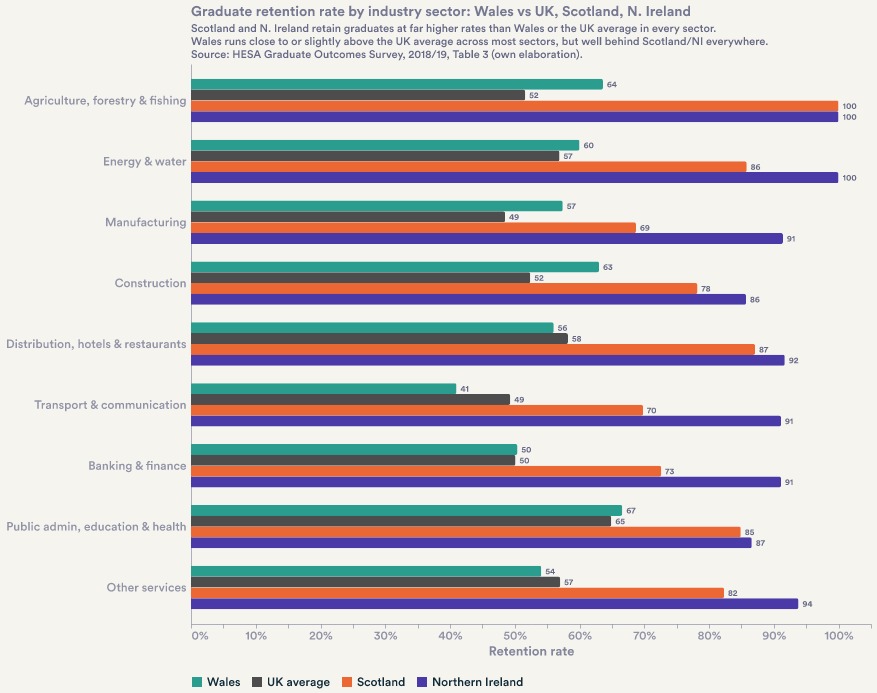

In [51]:
def sector_bar_chart(df, x_title, x_domain, chart_title, subtitle_lines, out_name):
    y_enc = alt.Y("sector:N", sort=SECTORS, title=None,
                  axis=alt.Axis(labelFontSize=12, labelLimit=260, grid=False))
    yoff  = alt.YOffset("region_label:N", sort=FOCUS_ORDER,
                        scale=alt.Scale(paddingOuter=0.3, paddingInner=0.1))
    x_enc = alt.X("rate:Q", title=x_title,
                  scale=alt.Scale(domain=x_domain, nice=False, zero=True),
                  axis=alt.Axis(grid=False, labelExpr="datum.value + \'%\'", labelFontSize=12, titleFontSize=13))
    color_enc = alt.Color("region_label:N", scale=COLOR_SCALE_T4,
                          legend=alt.Legend(title=None, orient="bottom", labelFontSize=12))
    tooltip = [
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("sector:N", title="Sector"),
        alt.Tooltip("rate:Q", title=x_title, format=".1f"),
    ]

    bars = alt.Chart(df).mark_bar(height=11, cornerRadiusTopRight=2, cornerRadiusBottomRight=2).encode(
        y=y_enc, yOffset=yoff, x=x_enc, color=color_enc, tooltip=tooltip)
    labels = alt.Chart(df).mark_text(align="left", dx=4, fontSize=8.5, fontWeight="bold").encode(
        y=y_enc, yOffset=yoff, x=x_enc, text=alt.Text("rate:Q", format=".0f"))

    chart = alt.layer(bars, labels).properties(
        width=680, height=560,
        title=alt.TitleParams(
            text=chart_title, subtitle=subtitle_lines,
            fontSize=14, subtitleFontSize=11, anchor="start",
        ),
    ).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

    chart.save(f"{CHARTS_DIR}/{out_name}.png", scale_factor=2.5)
    print(f"Saved {out_name}.png")
    return chart

chart_sector_retention = sector_bar_chart(
    table3_retention_long,
    x_title="Retention rate", x_domain=[0, 105],
    chart_title="Graduate retention rate by industry sector: Wales vs UK, Scotland, N. Ireland",
    subtitle_lines=[
        "Scotland and N. Ireland retain graduates at far higher rates than Wales or the UK average in every sector.",
        "Wales runs close to or slightly above the UK average across most sectors, but well behind Scotland/NI everywhere.",
        "Source: HESA Graduate Outcomes Survey, 2018/19, Table 3 (own elaboration).",
    ],
    out_name="graduate_sector_retention_wales_uk_scotland_ni",
)
chart_sector_retention


### Attraction rate by sector

Saved graduate_sector_attraction_wales_uk_scotland_ni.png


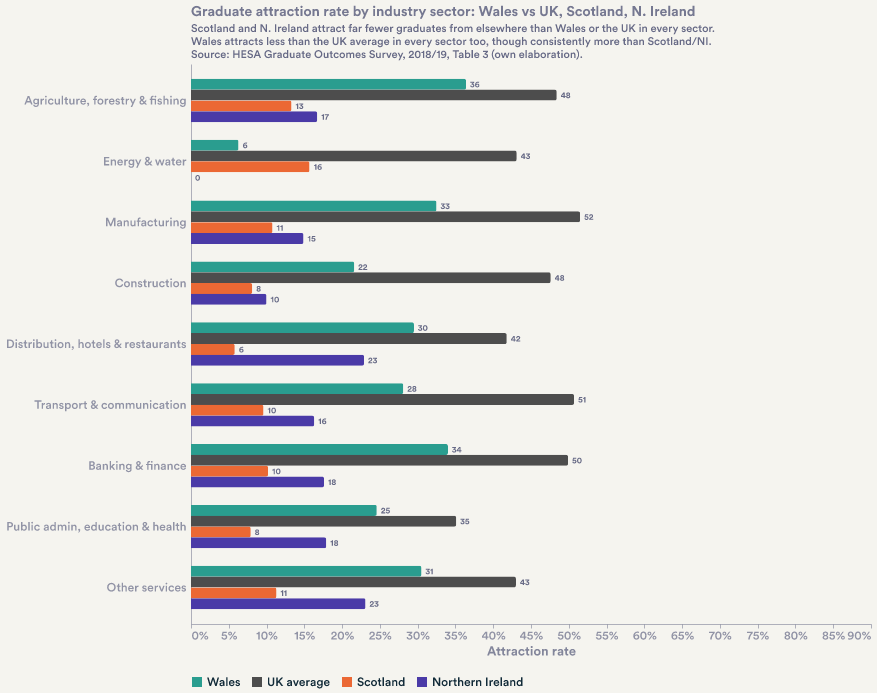

In [52]:
chart_sector_attraction = sector_bar_chart(
    table3_attraction_long,
    x_title="Attraction rate", x_domain=[0, 90],
    chart_title="Graduate attraction rate by industry sector: Wales vs UK, Scotland, N. Ireland",
    subtitle_lines=[
        "Scotland and N. Ireland attract far fewer graduates from elsewhere than Wales or the UK in every sector.",
        "Wales attracts less than the UK average in every sector too, though consistently more than Scotland/NI.",
        "Source: HESA Graduate Outcomes Survey, 2018/19, Table 3 (own elaboration).",
    ],
    out_name="graduate_sector_attraction_wales_uk_scotland_ni",
)
chart_sector_attraction


## 7b. Figure 1c — narrower scatter, plus Wales graduates aged 30+

Same simple-scatter design as Figure 1b, resized to 600×380, with one extra
point added: Wales graduates aged over 30 (retention 74.8%, attraction 19.8%)
— shown as a teal diamond to keep the Wales colour association while staying
visually distinct from the all-ages Wales dot.


Saved graduate_attraction_retention_uk_scatter_1c.png


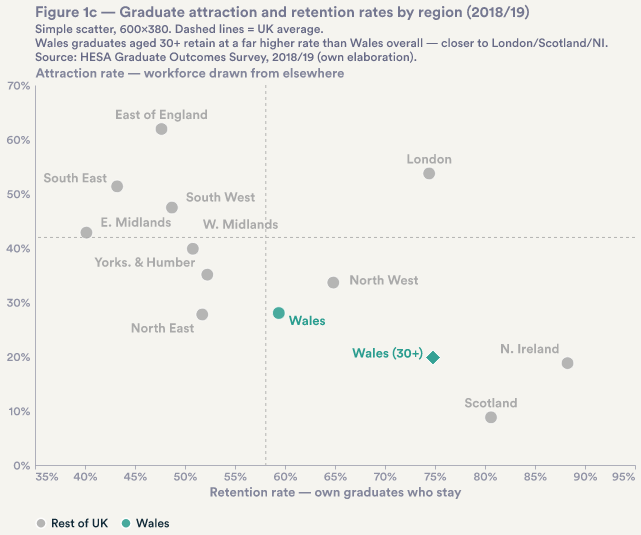

In [53]:
# ── Figure 1c — same design as 1b, resized, plus a Wales (30+) point ────────
fig1c = fig1.copy()
wales_30plus = pd.DataFrame([{
    "region": "Wales30", "region_label": "Wales (grads aged 30+)", "region_short": "Wales (30+)",
    "retention_rate": 74.8, "attraction_rate": 19.8, "is_wales": True,
}])

uk_h_c = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(y="y:Q")
uk_v_c = alt.Chart(uk_point).mark_rule(color="#888888", strokeDash=[3, 3], opacity=0.6).encode(x="x:Q")

dots_fig1c = alt.Chart(fig1c).mark_circle(size=160, opacity=0.85, stroke="white", strokeWidth=0.8).encode(
    x=alt.X("retention_rate:Q", title="Retention rate — own graduates who stay",
            scale=alt.Scale(domain=[35, 95], nice=False, zero=False),
            axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13)),
    y=alt.Y("attraction_rate:Q", title="Attraction rate — workforce drawn from elsewhere",
            scale=alt.Scale(domain=[0, 70], nice=False, zero=False),
            axis=alt.Axis(grid=False, labelExpr="datum.value + '%'", labelFontSize=12, titleFontSize=13)),
    color=alt.Color("is_wales:N", scale=COLOR_SCALE_FIG1,
                    legend=alt.Legend(title=None, orient="bottom", labelFontSize=12,
                                       labelExpr="datum.label == \'true\' ? \'Wales\' : \'Rest of UK\'")),
    tooltip=[
        alt.Tooltip("region_label:N", title="Region"),
        alt.Tooltip("retention_rate:Q", title="Retention rate", format=".1f"),
        alt.Tooltip("attraction_rate:Q", title="Attraction rate", format=".1f"),
    ],
)

# The extra point — same teal, diamond shape so it reads as a Wales variant,
# not a fifth region on equal footing with the rest.
dot_wales30 = alt.Chart(wales_30plus).mark_point(
    shape="diamond", size=220, filled=True, color=TEAL, stroke="white", strokeWidth=1,
).encode(
    x="retention_rate:Q", y="attraction_rate:Q",
    tooltip=[alt.Tooltip("region_label:N", title="Region"),
             alt.Tooltip("retention_rate:Q", title="Retention rate", format=".1f"),
             alt.Tooltip("attraction_rate:Q", title="Attraction rate", format=".1f")],
)

LABEL_POS = {
    "NE":    {"dx": -8,  "dy": 14,  "align": "right"},
    "NW":    {"dx": 16,  "dy": -2,  "align": "left"},
    "Y&H":   {"dx": -12, "dy": -12, "align": "right"},
    "WM":    {"dx": 10,  "dy": -24, "align": "left"},
    "Wales": {"dx": 10,  "dy": 8,   "align": "left"},
    "EM":    {"dx": 14,  "dy": -10, "align": "left"},
    "EE":    {"dx": 0,   "dy": -14, "align": "center"},
    "LD":    {"dx": 0,   "dy": -14, "align": "center"},
    "SE":    {"dx": -10, "dy": -8,  "align": "right"},
    "SW":    {"dx": 14,  "dy": -10, "align": "left"},
    "ST":    {"dx": 0,   "dy": -14, "align": "center"},
    "NI":    {"dx": -8,  "dy": -14, "align": "right"},
}

label_layers_c = []
for _, row in fig1c.iterrows():
    pos = LABEL_POS[row["region"]]
    label_layers_c.append(
        alt.Chart(pd.DataFrame([row])).mark_text(
            fontSize=13, fontWeight="bold",
            dx=pos["dx"], dy=pos["dy"], align=pos["align"],
            color=TEAL if row["is_wales"] else ENGLAND_GRAY,
        ).encode(x="retention_rate:Q", y="attraction_rate:Q", text="region_short:N")
    )

label_wales30 = alt.Chart(wales_30plus).mark_text(
    fontSize=13, fontWeight="bold", fontStyle="italic",
    dx=-10, dy=-4, align="right", color=TEAL,
).encode(x="retention_rate:Q", y="attraction_rate:Q", text="region_short:N")

chart_fig1c = alt.layer(uk_h_c, uk_v_c, dots_fig1c, dot_wales30, *label_layers_c, label_wales30).properties(
    width=600, height=380,
    title=alt.TitleParams(
        text="Figure 1c — Graduate attraction and retention rates by region (2018/19)",
        subtitle=[
            "Simple scatter, 600×380. Dashed lines = UK average.",
            "Wales graduates aged 30+ retain at a far higher rate than Wales overall — closer to London/Scotland/NI.",
            "Source: HESA Graduate Outcomes Survey, 2018/19 (own elaboration).",
        ],
        fontSize=15, subtitleFontSize=12, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background=BACKGROUND).configure_axis(grid=False)

chart_fig1c.save(f"{CHARTS_DIR}/graduate_attraction_retention_uk_scatter_1c.png", scale_factor=2.5)
print("Saved graduate_attraction_retention_uk_scatter_1c.png")

chart_fig1c


## 12. STEM share gap between stayers and leavers, by nation of birth

Dumbbell chart — one dot for the STEM share of graduates who stayed in their
home nation, one for those who left, joined by a connector. Sorted by gap size
(largest at top) so Wales's markedly wider gap reads immediately, while still
showing the two underlying shares that produce it (unlike a plain bar of the
gap column alone).

Source: Bristow et al. (2011), Table 10; Labour Force Survey 2006–2010;
post-1992 young graduates.


In [54]:
STEM_GAP_DATA = [
    {"nation": "Wales",            "stayers": 35.6, "leavers": 42.2},
    {"nation": "Scotland",         "stayers": 41.3, "leavers": 43.9},
    {"nation": "Northern Ireland", "stayers": 42.8, "leavers": 45.2},
    {"nation": "UK average",       "stayers": 40.2, "leavers": 43.6},
]
stem_gap = pd.DataFrame(STEM_GAP_DATA)
stem_gap["gap"] = (stem_gap["leavers"] - stem_gap["stayers"]).round(1)
stem_gap["is_wales"] = stem_gap["nation"] == "Wales"
stem_gap = stem_gap.sort_values("gap", ascending=False).reset_index(drop=True)
NATION_ORDER_GAP = stem_gap["nation"].tolist()

STAYER_COLOR = "#2a78d6"  # validated categorical blue
LEAVER_COLOR = "#eb6834"  # validated categorical orange
STATUS_SCALE = alt.Scale(domain=["Stayers", "Leavers"], range=[STAYER_COLOR, LEAVER_COLOR])

long_gap = stem_gap.melt(
    id_vars=["nation", "gap", "is_wales"], value_vars=["stayers", "leavers"],
    var_name="status", value_name="value",
)
long_gap["status_label"] = long_gap["status"].map({"stayers": "Stayers", "leavers": "Leavers"})

stem_gap.head()


,nation,stayers,leavers,gap,is_wales
0,Wales,35.6,42.2,6.6,True
1,UK average,40.2,43.6,3.4,False
2,Scotland,41.3,43.9,2.6,False
3,Northern Ireland,42.8,45.2,2.4,False


Saved stem_share_stayers_leavers_gap.png


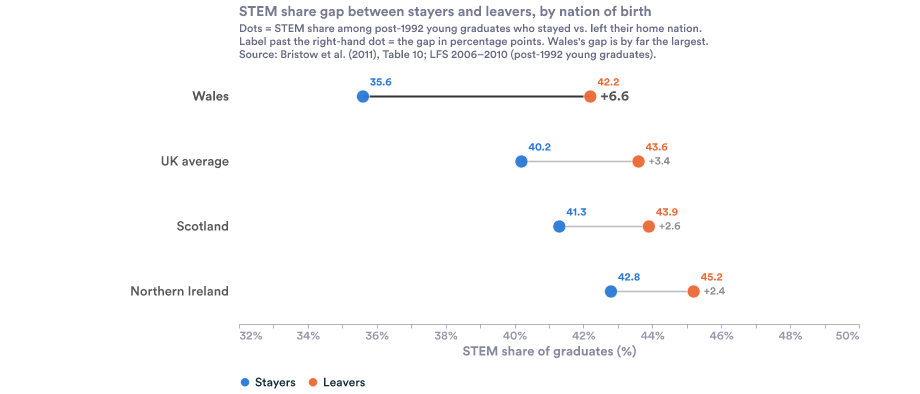

In [59]:
y_enc_gap = alt.Y("nation:N", sort=NATION_ORDER_GAP, title=None,
                  axis=alt.Axis(labels=False, ticks=False, domain=False))
x_enc_gap = alt.X("value:Q", title="STEM share of graduates (%)",
                  scale=alt.Scale(domain=[32, 50], nice=False, zero=False),
                  axis=alt.Axis(grid=False, labelExpr="datum.value + \'%\'", labelFontSize=12, titleFontSize=13))

# Connector — thicker and darker for Wales so the widest gap draws the eye first
connectors_gap = alt.Chart(stem_gap).mark_rule().encode(
    y=y_enc_gap,
    x=alt.X("stayers:Q", scale=alt.Scale(domain=[32, 50], nice=False, zero=False)),
    x2="leavers:Q",
    color=alt.condition("datum.is_wales", alt.value("#333333"), alt.value("#bbbbbb")),
    strokeWidth=alt.condition("datum.is_wales", alt.value(2), alt.value(1.5)),
)

dots_gap = alt.Chart(long_gap).mark_circle(size=170, opacity=0.95, stroke="white", strokeWidth=0.8).encode(
    y=alt.Y("nation:N", sort=NATION_ORDER_GAP),
    x=x_enc_gap,
    color=alt.Color("status_label:N", scale=STATUS_SCALE,
                    legend=alt.Legend(title=None, orient="bottom", labelFontSize=12)),
    tooltip=[alt.Tooltip("nation:N", title="Nation"), alt.Tooltip("status_label:N", title="Group"),
             alt.Tooltip("value:Q", title="STEM share", format=".1f")],
)

value_labels_gap = alt.Chart(long_gap).mark_text(
    fontSize=11, fontWeight="bold", dy=-14,
).encode(
    y=alt.Y("nation:N", sort=NATION_ORDER_GAP), x=x_enc_gap,
    text=alt.Text("value:Q", format=".1f"),
    color=alt.Color("status_label:N", scale=STATUS_SCALE, legend=None),
)

# Nation row labels — custom text at the plot's left edge (pixel 0). fontWeight
# isn't a data-drivable channel in Vega-Lite, so Wales gets its own statically
# bold+teal layer rather than a conditional encoding.
wales_row = stem_gap[stem_gap["is_wales"]]
rest_rows = stem_gap[~stem_gap["is_wales"]]

nation_labels_rest = alt.Chart(rest_rows).mark_text(
    align="right", dx=-10, fontSize=13, fontWeight="normal", color="#555555",
).encode(y=alt.Y("nation:N", sort=NATION_ORDER_GAP), x=alt.value(0), text="nation:N")
nation_labels_wales = alt.Chart(wales_row).mark_text(
    align="right", dx=-10, fontSize=13, fontWeight="bold", color="#555555",
).encode(y=alt.Y("nation:N", sort=NATION_ORDER_GAP), x=alt.value(0), text="nation:N")

# Gap callout — "+X.Xpp" past the leaver dot, bold + teal for Wales
x_leavers = alt.X("leavers:Q", scale=alt.Scale(domain=[32, 50], nice=False, zero=False))
gap_labels_rest = alt.Chart(rest_rows).mark_text(
    align="left", dx=10, fontStyle="italic", fontSize=11, fontWeight="normal", color="#888888",
).encode(y=alt.Y("nation:N", sort=NATION_ORDER_GAP), x=x_leavers, text=alt.Text("gap:Q", format="+.1f"))
gap_labels_wales = alt.Chart(wales_row).mark_text(
    align="left", dx=10, fontStyle="italic", fontSize=14, fontWeight="bold", color="#555555",
).encode(y=alt.Y("nation:N", sort=NATION_ORDER_GAP), x=x_leavers, text=alt.Text("gap:Q", format="+.1f"))

chart_stem_gap = alt.layer(
    connectors_gap, dots_gap, value_labels_gap,
    nation_labels_rest, nation_labels_wales, gap_labels_rest, gap_labels_wales,
).properties(
    width=620, height=260,
    padding={"left": 130, "top": 5, "right": 60, "bottom": 5},
    title=alt.TitleParams(
        text="STEM share gap between stayers and leavers, by nation of birth",
        subtitle=[
            "Dots = STEM share among post-1992 young graduates who stayed vs. left their home nation.",
            "Label past the right-hand dot = the gap in percentage points. Wales's gap is by far the largest.",
            "Source: Bristow et al. (2011), Table 10; LFS 2006–2010 (post-1992 young graduates).",
        ],
        fontSize=14, subtitleFontSize=11, anchor="start",
    ),
).configure_view(strokeWidth=0).configure(background="white").configure_axis(grid=False)

chart_stem_gap.save(f"{CHARTS_DIR}/stem_share_stayers_leavers_gap.png", scale_factor=2.5)
print("Saved stem_share_stayers_leavers_gap.png")

chart_stem_gap
